# Topic Modeling
This notebook covers topic distribution, dominant themes, prevalence by rating and geography, plus average rating and sentiment per topic.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
plt.style.use("seaborn-v0_8")

In [2]:
# Configuration
INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")
MIN_REVIEWS_GROUP = 20

In [3]:
# Load dataset
df = pd.read_csv(INPUT_FILE)

print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required_cols = [
    "Dominant_Topic",
    "Topic_Keywords",
    "Review_Theme",
    "Rating",
    "Combined_Sentiment"
]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

Loaded: Processed_Reviews.csv
Shape: (16156, 41)
Columns:
['Location_Name', 'Located_City', 'Province', 'District', 'Location_Type', 'User_Locale', 'User_Country', 'User_Region', 'Travel_Date_Month', 'Travel_Date_Year', 'Published_Date_Month', 'Published_Date_Year', 'User_Contributions', 'Rating', 'Helpful_Votes', 'Review_Length', 'Title_Length', 'Rating_Class', 'Review_Delay_Days', 'Combined_Text', 'Combined_Sentiment', 'Sentiment_Score', 'Emotion', 'Dominant_Topic', 'Topic_Probability', 'Topic_Keywords', 'Review_Theme', 'Sentiment_Rating_Gap', 'Length_Bucket', 'Has_Helpful_Votes', 'Helpfulness_Ratio', 'Helpful_Bucket', 'Reviewer_Experience', 'Sentiment_Numeric', 'Location_Avg_Rating', 'Location_Review_Count', 'Location_Sentiment_Mean', 'Rank_By_Rating', 'Rank_By_Popularity', 'Popularity_Quality_Gap', 'Review_Quality_Score']


In [4]:
# Topic distribution and themes
print("=== Dominant Topic Distribution ===")
print(df["Dominant_Topic"].value_counts().sort_index())

print("\n=== Review Theme Distribution ===")
theme_counts = df["Review_Theme"].value_counts()
print(theme_counts)

print("\n=== Review Theme Percentage Distribution ===")
print((theme_counts / theme_counts.sum() * 100).round(2))

=== Dominant Topic Distribution ===
Dominant_Topic
-1      4029
 0      1604
 1      1037
 2       581
 3       333
        ... 
 132      11
 133      10
 134      10
 135      10
 136      10
Name: count, Length: 138, dtype: int64

=== Review Theme Distribution ===
Review_Theme
Other                  12057
Scenery                 1604
Cultural Experience     1037
Service Quality          581
Crowding & Pricing       333
Food & Hospitality       298
Wildlife & Nature        246
Name: count, dtype: int64

=== Review Theme Percentage Distribution ===
Review_Theme
Other                  74.63
Scenery                 9.93
Cultural Experience     6.42
Service Quality         3.60
Crowding & Pricing      2.06
Food & Hospitality      1.84
Wildlife & Nature       1.52
Name: count, dtype: float64


In [5]:
# Topic summary table
topic_summary = (
    df.groupby(["Dominant_Topic", "Review_Theme", "Topic_Keywords"])
      .agg(
          Review_Count=("Dominant_Topic", "count"),
          Avg_Rating=("Rating", "mean")
      )
      .reset_index()
      .sort_values(by="Review_Count", ascending=False)
)

print("=== Topic Summary (top 20) ===")
print(topic_summary.head(20))

=== Topic Summary (top 20) ===
    Dominant_Topic         Review_Theme  \
0               -1                Other   
1                0              Scenery   
2                1  Cultural Experience   
3                2      Service Quality   
4                3   Crowding & Pricing   
5                4   Food & Hospitality   
6                5    Wildlife & Nature   
7                6                Other   
8                7                Other   
9                8                Other   
10               9                Other   
11              10                Other   
12              11                Other   
13              12                Other   
14              13                Other   
15              14                Other   
16              15                Other   
17              16                Other   
18              17                Other   
19              18                Other   

                                                                 

In [6]:
# Average rating by theme
theme_rating_summary = (
    df.groupby("Review_Theme")
      .agg(Review_Count=("Review_Theme", "count"), Avg_Rating=("Rating", "mean"))
      .reset_index()
)
theme_rating_summary = theme_rating_summary[
    theme_rating_summary["Review_Count"] >= MIN_REVIEWS_GROUP
].sort_values(by="Avg_Rating", ascending=False)

print(f"=== Average Rating by Theme (min {MIN_REVIEWS_GROUP} reviews) ===")
print(theme_rating_summary)

# Average sentiment by theme
if "Sentiment_Numeric" in df.columns:
    theme_sentiment_summary = (
        df.groupby("Review_Theme")
          .agg(Review_Count=("Review_Theme", "count"), Avg_Sentiment=("Sentiment_Numeric", "mean"))
          .reset_index()
    )
    theme_sentiment_summary = theme_sentiment_summary[
        theme_sentiment_summary["Review_Count"] >= MIN_REVIEWS_GROUP
    ].sort_values(by="Avg_Sentiment", ascending=False)
    print(f"\n=== Average Sentiment by Theme (min {MIN_REVIEWS_GROUP} reviews) ===")
    print(theme_sentiment_summary)
else:
    theme_sentiment_summary = None

=== Average Rating by Theme (min 20 reviews) ===
          Review_Theme  Review_Count  Avg_Rating
6    Wildlife & Nature           246    4.317073
0   Crowding & Pricing           333    4.204204
3                Other         12057    4.193912
4              Scenery          1604    4.145262
1  Cultural Experience          1037    4.027001
5      Service Quality           581    4.018933
2   Food & Hospitality           298    3.832215

=== Average Sentiment by Theme (min 20 reviews) ===
          Review_Theme  Review_Count  Avg_Sentiment
0   Crowding & Pricing           333       0.759760
5      Service Quality           581       0.752151
6    Wildlife & Nature           246       0.739837
3                Other         12057       0.706726
2   Food & Hospitality           298       0.644295
1  Cultural Experience          1037       0.608486
4              Scenery          1604       0.607232


In [7]:
# Theme vs rating prevalence
theme_rating_crosstab = pd.crosstab(df["Review_Theme"], df["Rating"])
print("=== Theme vs Rating Crosstab ===")
print(theme_rating_crosstab)

theme_rating_pct = pd.crosstab(
    df["Review_Theme"], df["Rating"], normalize="index"
).round(3) * 100

print("\n=== Theme vs Rating Percentage ===")
print(theme_rating_pct)

# Theme vs sentiment prevalence
theme_sentiment_crosstab = pd.crosstab(df["Review_Theme"], df["Combined_Sentiment"])
print("\n=== Theme vs Sentiment Crosstab ===")
print(theme_sentiment_crosstab)

theme_sentiment_pct = pd.crosstab(
    df["Review_Theme"], df["Combined_Sentiment"], normalize="index"
).round(3) * 100

print("\n=== Theme vs Sentiment Percentage ===")
print(theme_sentiment_pct)

=== Theme vs Rating Crosstab ===
Rating                 1    2     3     4     5
Review_Theme                                   
Crowding & Pricing     7   16    37   115   158
Cultural Experience   39   68   169   311   450
Food & Hospitality     6   25    65   119    83
Other                305  455  1591  3952  5754
Scenery              110   64   173   393   864
Service Quality       20   26   100   212   223
Wildlife & Nature      0    4    31    94   117

=== Theme vs Rating Percentage ===
Rating                 1    2     3     4     5
Review_Theme                                   
Crowding & Pricing   2.1  4.8  11.1  34.5  47.4
Cultural Experience  3.8  6.6  16.3  30.0  43.4
Food & Hospitality   2.0  8.4  21.8  39.9  27.9
Other                2.5  3.8  13.2  32.8  47.7
Scenery              6.9  4.0  10.8  24.5  53.9
Service Quality      3.4  4.5  17.2  36.5  38.4
Wildlife & Nature    0.0  1.6  12.6  38.2  47.6

=== Theme vs Sentiment Crosstab ===
Combined_Sentiment   NEGATIVE 

In [8]:
# Theme distribution by location type
if "Location_Type" in df.columns:
    theme_by_type = pd.crosstab(df["Location_Type"], df["Review_Theme"])
    print("=== Theme by Location Type ===")
    print(theme_by_type)
else:
    theme_by_type = None

# Theme distribution by city (top 10)
if "Located_City" in df.columns:
    top_cities = df["Located_City"].value_counts().head(10).index
    city_theme_summary = pd.crosstab(
        df[df["Located_City"].isin(top_cities)]["Located_City"],
        df[df["Located_City"].isin(top_cities)]["Review_Theme"]
    )
    print("\n=== Theme Distribution in Top 10 Cities ===")
    print(city_theme_summary)
else:
    city_theme_summary = None

=== Theme by Location Type ===
Review_Theme             Crowding & Pricing  Cultural Experience  \
Location_Type                                                      
Beaches                                   1                 1015   
Bodies of Water                           0                    2   
Farms                                   235                    0   
Gardens                                   0                    1   
Historic Sites                            3                    4   
Museums                                  92                    3   
National Parks                            0                    2   
Nature & Wildlife Areas                   0                    1   
Religious Sites                           0                    4   
Waterfalls                                2                    5   
Zoological Gardens                        0                    0   

Review_Theme             Food & Hospitality  Other  Scenery  Service Quality  \
Loca

In [9]:
# Top example reviews per theme
if "Text" in df.columns and "Sentiment_Score" in df.columns:
    example_reviews = (
        df.sort_values(by="Sentiment_Score", ascending=False)
          .groupby("Review_Theme")
          .head(3)[["Review_Theme", "Rating", "Combined_Sentiment", "Text"]]
    )
    print("=== Example Reviews by Theme ===")
    print(example_reviews.head(20))
else:
    example_reviews = None

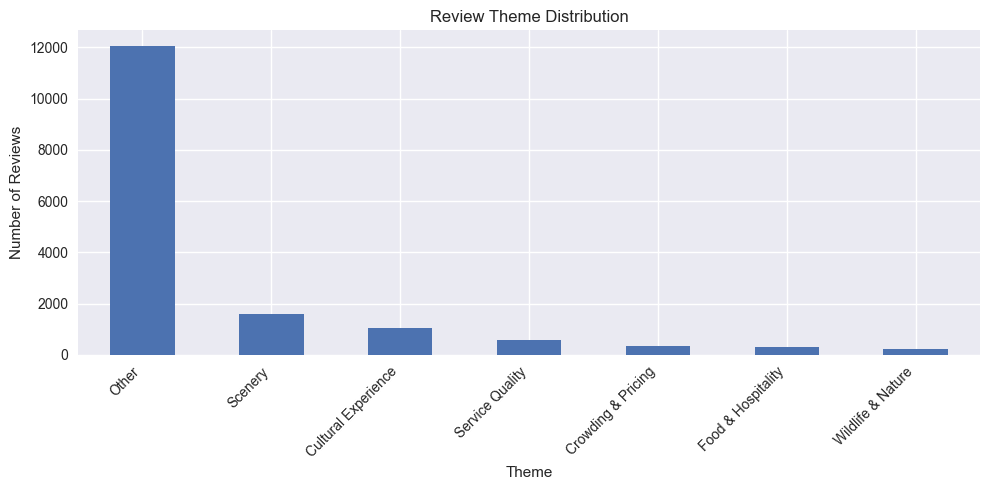

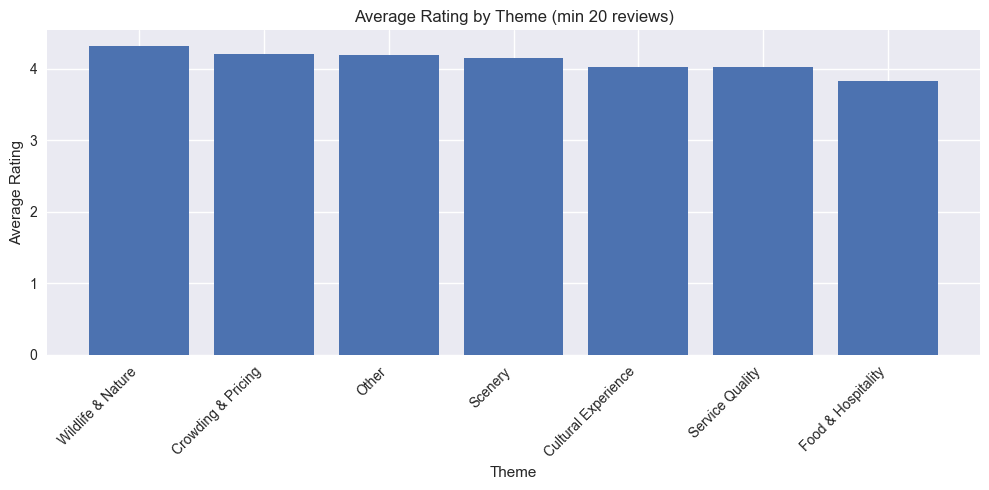

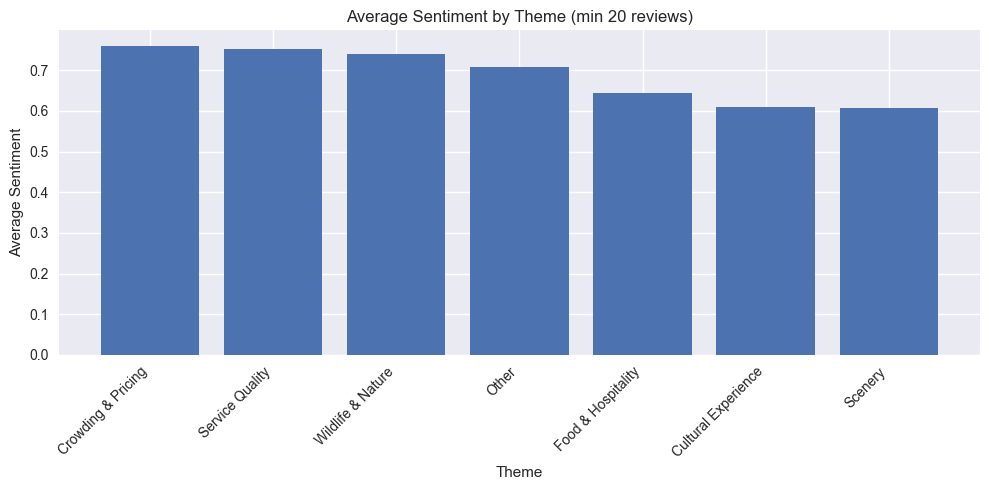

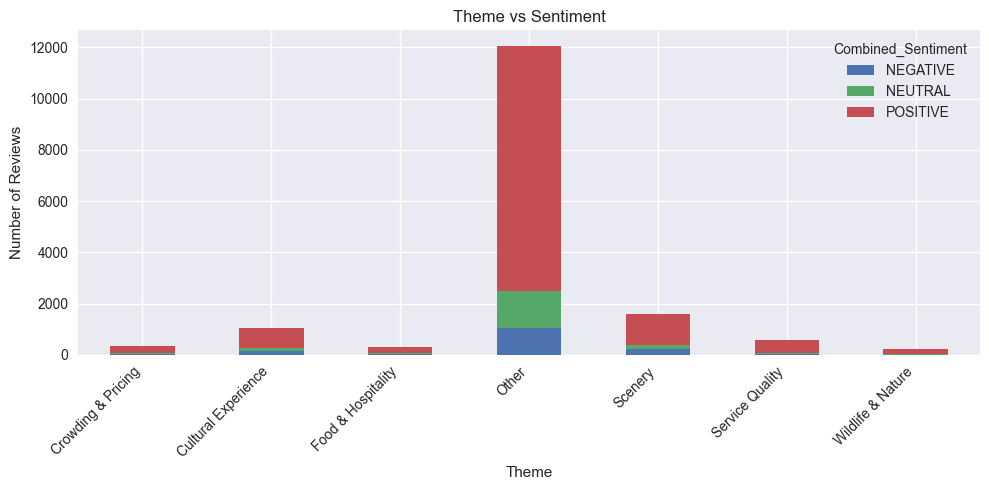

In [10]:
# Plots
plt.figure(figsize=(10, 5))
theme_counts.plot(kind="bar")
plt.title("Review Theme Distribution")
plt.xlabel("Theme")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if not theme_rating_summary.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(theme_rating_summary["Review_Theme"], theme_rating_summary["Avg_Rating"])
    plt.title(f"Average Rating by Theme (min {MIN_REVIEWS_GROUP} reviews)")
    plt.xlabel("Theme")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if theme_sentiment_summary is not None and not theme_sentiment_summary.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(theme_sentiment_summary["Review_Theme"], theme_sentiment_summary["Avg_Sentiment"])
    plt.title(f"Average Sentiment by Theme (min {MIN_REVIEWS_GROUP} reviews)")
    plt.xlabel("Theme")
    plt.ylabel("Average Sentiment")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

theme_sentiment_crosstab.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Theme vs Sentiment")
plt.xlabel("Theme")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Save outputs
topic_summary.to_csv("topic_summary.csv", index=False)
theme_rating_summary.to_csv("theme_rating_summary.csv", index=False)
theme_rating_crosstab.to_csv("theme_rating_crosstab.csv")
theme_rating_pct.to_csv("theme_rating_percentage.csv")
theme_sentiment_crosstab.to_csv("theme_sentiment_crosstab.csv")
theme_sentiment_pct.to_csv("theme_sentiment_percentage.csv")

if theme_sentiment_summary is not None:
    theme_sentiment_summary.to_csv("theme_sentiment_summary.csv", index=False)

if theme_by_type is not None:
    theme_by_type.to_csv("theme_by_location_type.csv")

if city_theme_summary is not None:
    city_theme_summary.to_csv("theme_by_top_cities.csv")

if example_reviews is not None:
    example_reviews.to_csv("example_reviews_by_theme.csv", index=False)

print("✅ Topic modeling / opinion mining analysis complete.")
print("Saved files:")
print("- topic_summary.csv")
print("- theme_rating_summary.csv")
print("- theme_rating_crosstab.csv")
print("- theme_rating_percentage.csv")
print("- theme_sentiment_crosstab.csv")
print("- theme_sentiment_percentage.csv")
if theme_sentiment_summary is not None:
    print("- theme_sentiment_summary.csv")
if theme_by_type is not None:
    print("- theme_by_location_type.csv")
if city_theme_summary is not None:
    print("- theme_by_top_cities.csv")
if example_reviews is not None:
    print("- example_reviews_by_theme.csv")

✅ Topic modeling / opinion mining analysis complete.
Saved files:
- topic_summary.csv
- theme_rating_summary.csv
- theme_rating_crosstab.csv
- theme_rating_percentage.csv
- theme_sentiment_crosstab.csv
- theme_sentiment_percentage.csv
- theme_sentiment_summary.csv
- theme_by_location_type.csv
- theme_by_top_cities.csv
